# Import

In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, adjusted_rand_score

In [2]:
#Analyse one image first
image_path = '/content/dataset_path/Screenshot (190).png' # Replace with image path

# Load image
img = cv2.imread(image_path)

# Check if loading was successful
if img is None:
    print(f"Error: Unable to load image from {image_path}.")






# Image analysis

In [ ]:
# Bruh, there is no data analysis question

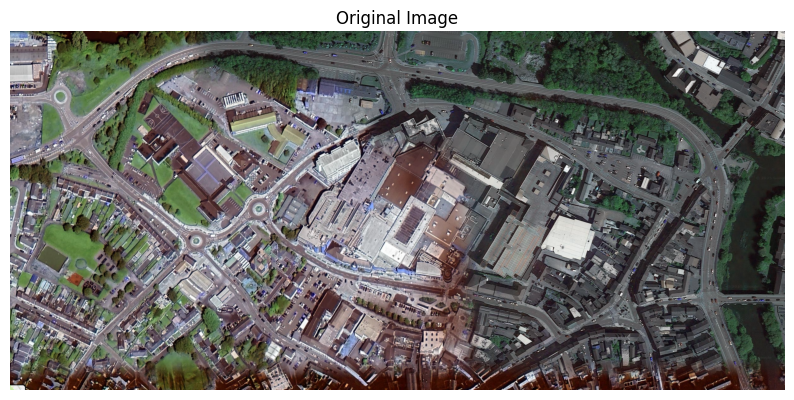

In [3]:
#convert from float array to np int
fig, axes = plt.subplots(1, figsize=(10,10))
axes.imshow(img.astype(np.uint8))
axes.set_title("Original Image")
axes.axis('off')
plt.show()

In [4]:
#there is no multiband spectral data, which could
# have been useful for urban settlement segmentation
#instead manually take rgb channels and measure urban and green regions
# Extract RGB channels
red = img[:, :, 0]
green = img[:, :, 1]
blue = img[:, :, 2]

# Approximate NDBI (built-up areas)
ndbi_rgb = (red - green) / (red + green + 1e-10)

# Approximate NDVI (vegetation)
ndvi_rgb = (green - red) / (green + red + 1e-10)




In [5]:
# thresholds
veg_threshold = 0.5   # Higher NDVI = more vegetation
urban_threshold = 1   # Higher NDBI = more built-up

# masks
vegetation_mask = ndbi_rgb > veg_threshold
urban_mask = ndvi_rgb > urban_threshold

# Apply mask to image
vegetation_only = np.zeros_like(img)
urban_only = np.zeros_like(img)

vegetation_only[vegetation_mask] = img[vegetation_mask]
urban_only[urban_mask] = img[urban_mask]



In [6]:
# Calculate percentage of image
percentage_vegetation = (np.sum(vegetation_mask) / vegetation_mask.size) * 100
print(f"Percentage of vegetation: {percentage_vegetation:.2f}%")

percentage_urban = (np.sum(urban_mask) / urban_mask.size) * 100
print(f"Percentage of urban: {percentage_urban:.2f}%")

Percentage of vegetation: 49.90%
Percentage of urban: 50.11%


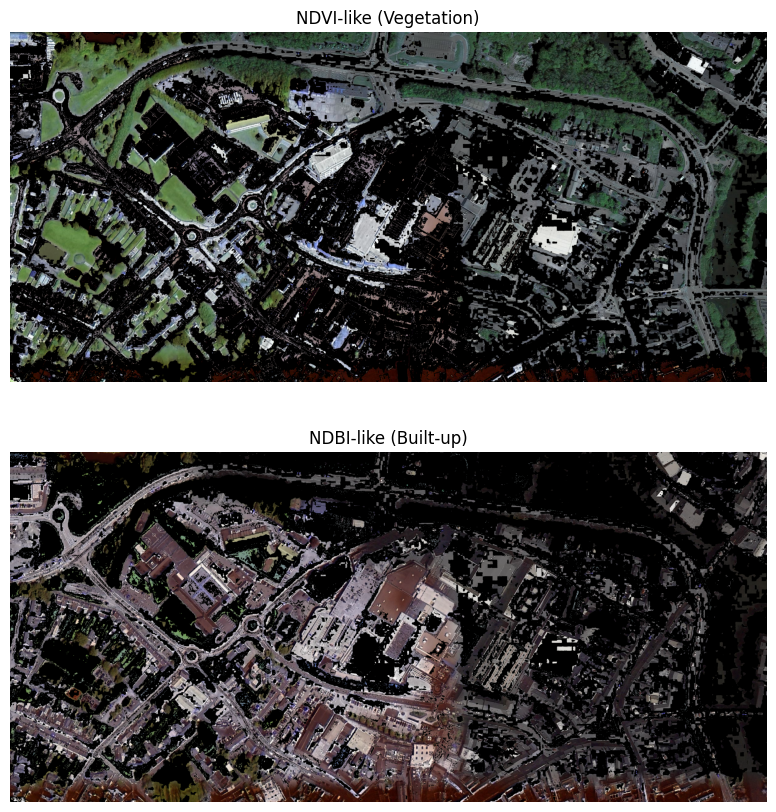

In [7]:
# Plot
fig, axes = plt.subplots(2, 1, figsize=(10,10))
axes[0].imshow(vegetation_only, cmap = 'Greens')
axes[0].set_title("NDVI-like (Vegetation)")
axes[1].imshow(urban_only, cmap='gray')
axes[1].set_title("NDBI-like (Built-up)")

for ax in axes:
    ax.axis('off')
plt.show()

In [8]:
# Handle overlapping classifications (priority: urban > Vegetation)
final_classification = np.zeros(img.shape[:2], dtype=np.uint8)

# VEGETATION first (lower priority)
final_classification[vegetation_mask] = 1  # Vegetation = 1

# Then URBAN (highest priority - overwrites vegetation where they overlap)
final_classification[urban_mask] = 2  # Urban = 2

# Calculate total pixels (use the 2D shape, not the full image size with channels)
total_pixels = img.shape[0] * img.shape[1]

# Calculate percentages with correct labels
veg_percentage = (np.sum(final_classification == 1) / total_pixels) * 100  # Vegetation
urban_percentage = (np.sum(final_classification == 2) / total_pixels) * 100  # Urban
other_percentage = (np.sum(final_classification == 0) / total_pixels) * 100  # Other

print(f"Vegetation area: {veg_percentage:.2f}%")
print(f"Urban/Built-up area: {urban_percentage:.2f}%")
print(f"Other areas: {other_percentage:.2f}%")
print(f"Total: {veg_percentage + urban_percentage + other_percentage:.1f}%")

Vegetation area: 44.22%
Urban/Built-up area: 50.11%
Other areas: 5.68%
Total: 100.0%


# PCA

In [9]:
img_resized = cv2.resize(img, (300, 300))
# Flatten the image pixels for kmeans
pixels = img_resized.reshape(-1, 3)  # RGB

# Apply PCA to reduce to 2 or 3 dimensions for clustering
pca = PCA(n_components=2)
pixels_pca = pca.fit_transform(pixels)

# KNN + PCA

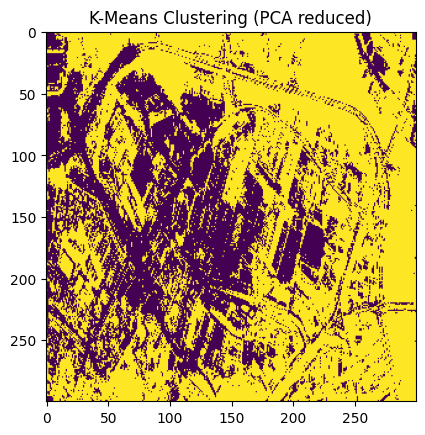

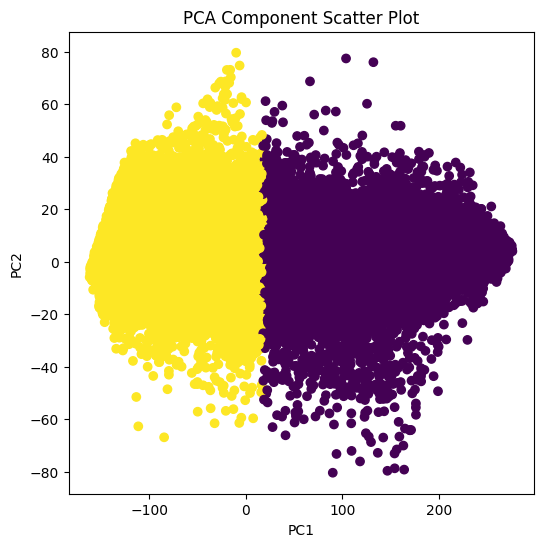

In [10]:
#K-means on reduced features
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(pixels_pca)
clustered = kmeans.labels_.reshape(img_resized.shape[:2])

plt.imshow(clustered)
plt.title("K-Means Clustering (PCA reduced)")
plt.show()

#PCA scatter plot

plt.figure(figsize=(6,6))
plt.scatter(pixels_pca[:, 0], pixels_pca[:, 1], c=clustered, cmap='viridis')
plt.title('PCA Component Scatter Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# SVM on full image set

In [11]:
def load_and_augment(files, folder):
    images = []
    for filename in files:
        img = cv2.imread(os.path.join(folder, filename))
        img_resized = cv2.resize(img, (120, 120))  # Resize all images to same size
        augmented = [img_resized]
        augmented.append(cv2.flip(img_resized, 1))  # Horizontal flip
        augmented.append(cv2.flip(img_resized, 0))  # Vertical flip
        augmented = [im.astype(np.float32)/255.0 for im in augmented]  # Normalize
        images.extend(augmented)
    return np.array(images)


In [12]:

folder_path = "/content/dataset_path"
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]


# Split into train/test
train_files, test_files = train_test_split(image_files, test_size=0.2, random_state=42)

train_images = load_and_augment(train_files, folder_path)
test_images = load_and_augment(test_files, folder_path)



In [13]:
#CLASSIFY THE IMAGES SET, NOT ALL THE PIXELS

# [0] indicates the number of images
X_train = train_images.reshape(train_images.shape[0], -1)
X_test = test_images.reshape(test_images.shape[0], -1)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
n_components = min(X_train.shape[0], X_train.shape[1])
pca = PCA(n_components=n_components)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [15]:
# Train KMeans and get labels
kmeans = KMeans(n_clusters=2, random_state=42)
train_labels = kmeans.fit_predict(X_train)

test_kmeans_labels = kmeans.predict(X_test)

In [16]:
# Train SVM and get labels
model = SVC(kernel='rbf', random_state=42)
model.fit(X_train, train_labels)

test_labels_pred = model.predict(X_test)

In [25]:
# Additional metrics

accuracy = accuracy_score(test_kmeans_labels, test_labels_pred)
ari = adjusted_rand_score(test_kmeans_labels, test_labels_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Adjusted Rand Index: {ari:.2f}") # similarity between clusters

Accuracy: 0.56
Adjusted Rand Index: -0.11
